# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [22]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [7]:
# 1. Leer el archivo CSV proveniente de la carpeta data/raw/
df = pd.read_csv("../data/raw/housing/housing.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# 2. Analizar la estructura del dataset: tipos de datos, valores faltantes, estadísticas descriptivas.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


Del análisis de la estructura, se visualizan datos faltantes en total_bedrooms. 
El detalle de las columnas se muestran a continuación:
- longitude → Longitud (coordenada geográfica oeste–este).
- latitude → Latitud (coordenada geográfica norte–sur).
- housing_median_age → Edad mediana de las viviendas del área.
- total_rooms → Total de cuartos en todas las viviendas del área.
- total_bedrooms → Total de dormitorios en todas las viviendas del área.
- population → Número total de personas que viven en el área.
- households → Número total de hogares (grupos de personas que comparten vivienda).
- median_income → Ingreso mediano de los hogares (en decenas de miles de dólares).
- median_house_value → Valor mediano de las viviendas (variable objetivo).
- ocean_proximity → Categoría que indica qué tan cerca está el área del océano.

In [9]:
# estadísticas descriptivas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [37]:
#completitud
df.isnull().sum()
# porcentaje de valores faltantes
faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100
print(porcentaje_faltantes)

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


In [24]:
# precisión, duplicados
duplicados = df.duplicated().sum()
duplicados

np.int64(0)

In [25]:
# Consistencia (tipos y categorías)
print(df.dtypes)
print()
print(df["ocean_proximity"].value_counts())

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [26]:
# outliers
iqr = df["median_house_value"].quantile(0.75) - df["median_house_value"].quantile(0.25)
limite_inferior = df["median_house_value"].quantile(0.25) - 1.5 * iqr
limite_superior = df["median_house_value"].quantile(0.75) + 1.5 * iqr
outliers = df[(df["median_house_value"] < limite_inferior) | (df["median_house_value"] > limite_superior)]
print(f"Cantidad de outliers: {len(outliers)}")

Cantidad de outliers: 1071


Text(0.5, 1.0, 'Boxplot de median_house_value')

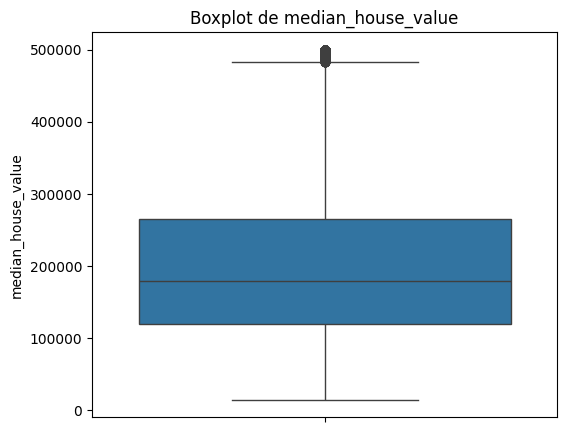

In [27]:
# gráfico de outliers con bigotes hacia arriba y abajo
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["median_house_value"])
plt.title("Boxplot de median_house_value")

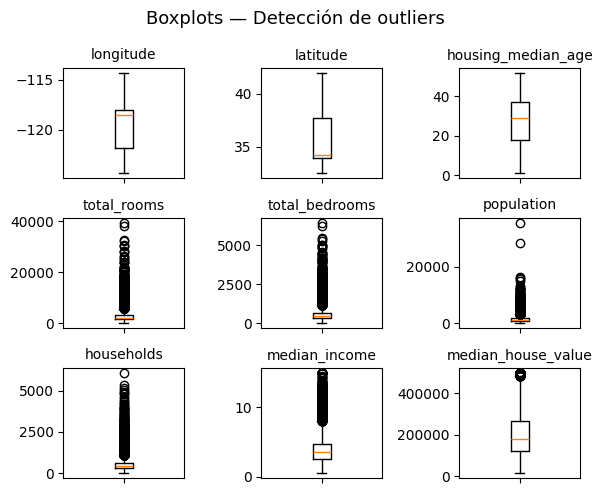

In [28]:
numericas = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(3, 3, figsize=(6, 5))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels([])

plt.suptitle("Boxplots — Detección de outliers", fontsize=13)
plt.tight_layout()
plt.show()

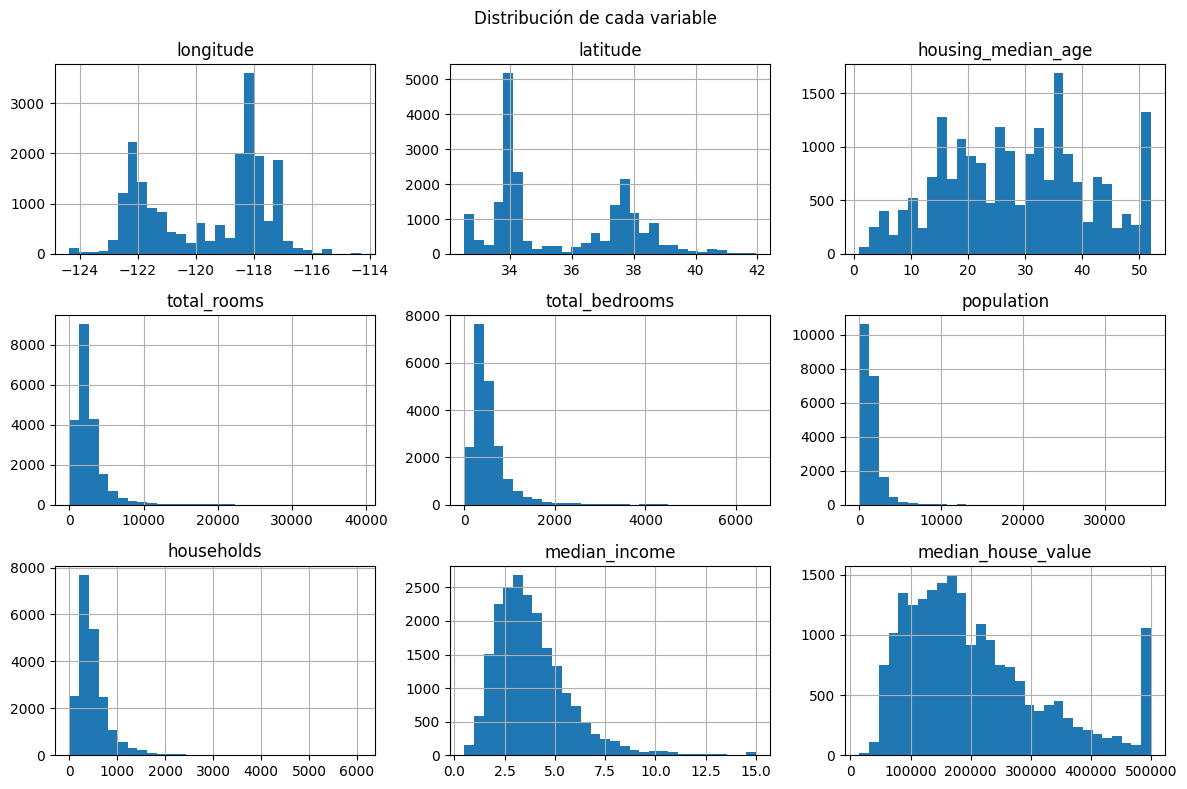

In [31]:
# Un histograma por cada variable numérica
df.hist(figsize=(12, 8), bins=30)

plt.suptitle("Distribución de cada variable")
plt.tight_layout()
plt.show()

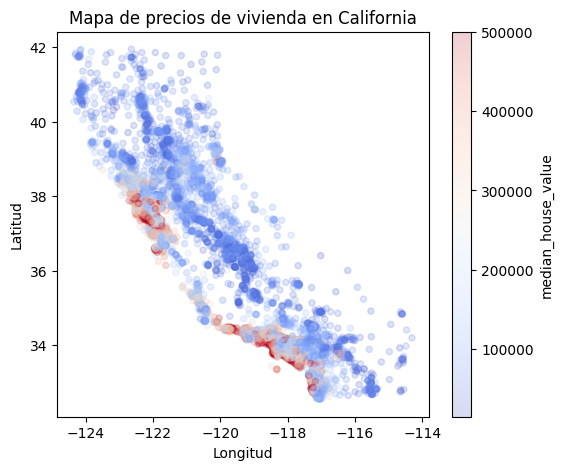

In [33]:
# Usamos longitud y latitud para ubicar cada vivienda en el mapa
# El color representa el precio: rojo = caro, azul = barato
df.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    c="median_house_value",
    cmap="coolwarm",
    figsize=(6, 5),
    colorbar=True
)

plt.title("Mapa de precios de vivienda en California")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [34]:
# .corr() calcula qué tan relacionada está cada variable con las demás
# Nos quedamos solo con la columna del precio
correlaciones = df.corr(numeric_only=True)["median_house_value"]

# Ordenamos de mayor a menor correlación
correlaciones.sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

#### Conclusiones de la exploración

##### Consistencia
- Consistencia: `ocean_proximity` es texto con 5 categorías.
  Necesitamos convertirla a números.
- Sensibilidad: `median_house_value` tiene un techo en $500,001.
  Muchas viviendas aparecen con ese valor exacto, lo que parece raro.
- Completitud: La columna `total_bedrooms` tiene valores ausentes (1.002907%).
  Es necesario llenar los valores faltantes.
- Precisión: No hay filas duplicadas en el dataset.
- Correlación más fuerte: `median_income` (ingreso del vecindario)
  es la variable más relacionada con el precio de la vivienda.
- Patrón geográfico: Las viviendas más caras están en la costa
  (San Francisco y Los Ángeles).